# INTRO

In [8]:
# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [2]:
# Create sample clustered data
X, y = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

In [3]:
# Convert to dataframe
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [4]:
inertia = []

# Test K values from 1 to 10
K = range(1, 11)

In [5]:
for k in K:

    # Create KMeans model
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Fit model
    kmeans.fit(X_scaled)

    # Store inertia value
    inertia.append(kmeans.inertia_)


In [6]:
inertia

[600.0000000000001,
 315.49253762478224,
 71.68831894273333,
 17.46619760906057,
 15.64897843542128,
 13.852405489607474,
 12.957971064628973,
 11.39397927346712,
 9.905114559538285,
 8.854600866913096]

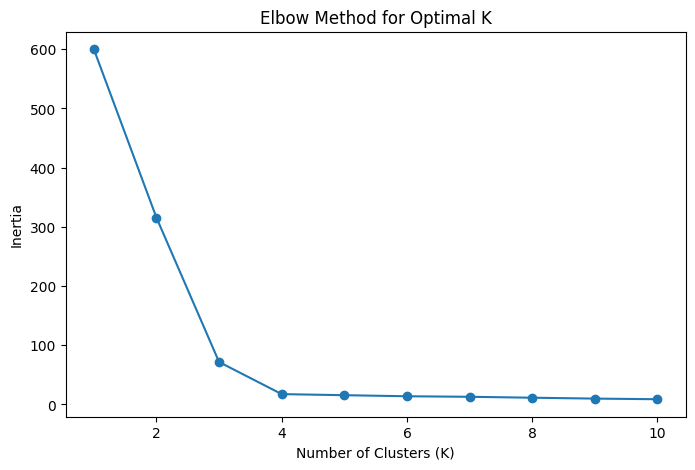

In [12]:
# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [13]:
# Plot Elbow Curveplt.figure(figsize=(8,5))plt.plot(K, inertia, marker='o')plt.xlabel("Number of Clusters (K)")plt.ylabel("Inertia")plt.title("Elbow Method for Optimal K")plt.show()

In [14]:
# Fit model and predict clusters
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [15]:
# Display clustered data
df.head()

,Feature_1,Feature_2,Cluster
0,-9.297689,6.473679,3
1,-9.698741,6.938967,3
2,-1.686653,7.793442,6
3,-7.097308,-5.781333,4
4,-10.876452,6.315437,3


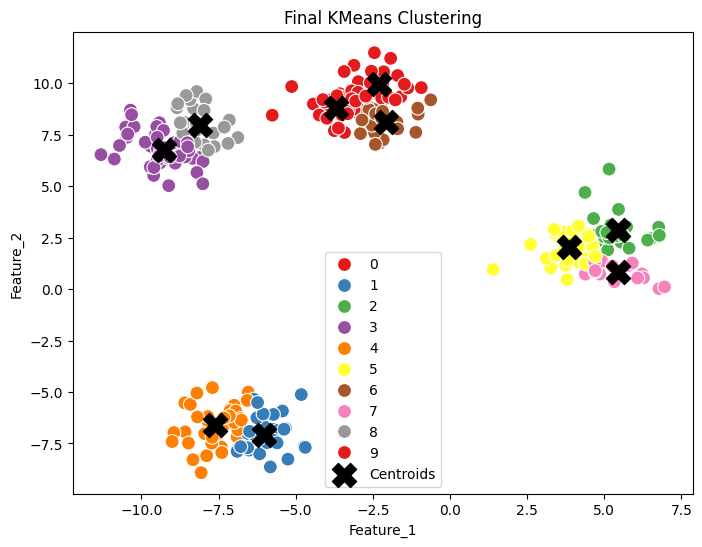

In [16]:
# =========================
# Visualize Clusters
# =========================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['Cluster'],
    palette='Set1',
    s=100
)

# Plot centroids
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='black',
    s=300,
    marker='X',
    label='Centroids'
)

plt.title("Final KMeans Clustering")
plt.legend()

plt.show()



1.   Disadvantages of KMeans Clustering

1. Need to choose the number of clusters (K) manually.

2. Sensitive to outliers and noise in the data.

3. Works poorly with non-spherical or unevenly sized clusters.

4. Different initial centroids can produce different results.

5. Assumes clusters have similar density and shape.

6. Not suitable for categorical data directly.

7. Performance decreases on very large datasets.

8. May converge to local optimum instead of global optimum.



# DBSCAN

In [18]:

from sklearn.datasets import make_moons


In [19]:
X, y = make_moons(
    n_samples=300,
    noise=0.05,
    random_state=42
)


In [20]:
from sklearn.cluster import KMeans, DBSCAN

In [21]:

# Convert to dataframe
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [23]:
# =========================
# Scale Data
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# =========================
# Apply KMeans
# =========================

kmeans = KMeans(
    n_clusters=2,
    random_state=42
)


In [24]:
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

In [25]:
# =========================
# Apply DBSCAN
# =========================

dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

In [26]:
df.head()

,Feature_1,Feature_2,KMeans_Cluster,DBSCAN_Cluster
0,0.622519,-0.372101,1,0
1,1.904269,-0.136303,1,0
2,-0.069431,0.456117,0,0
3,0.933899,0.237483,1,1
4,1.180360,-0.490847,1,0


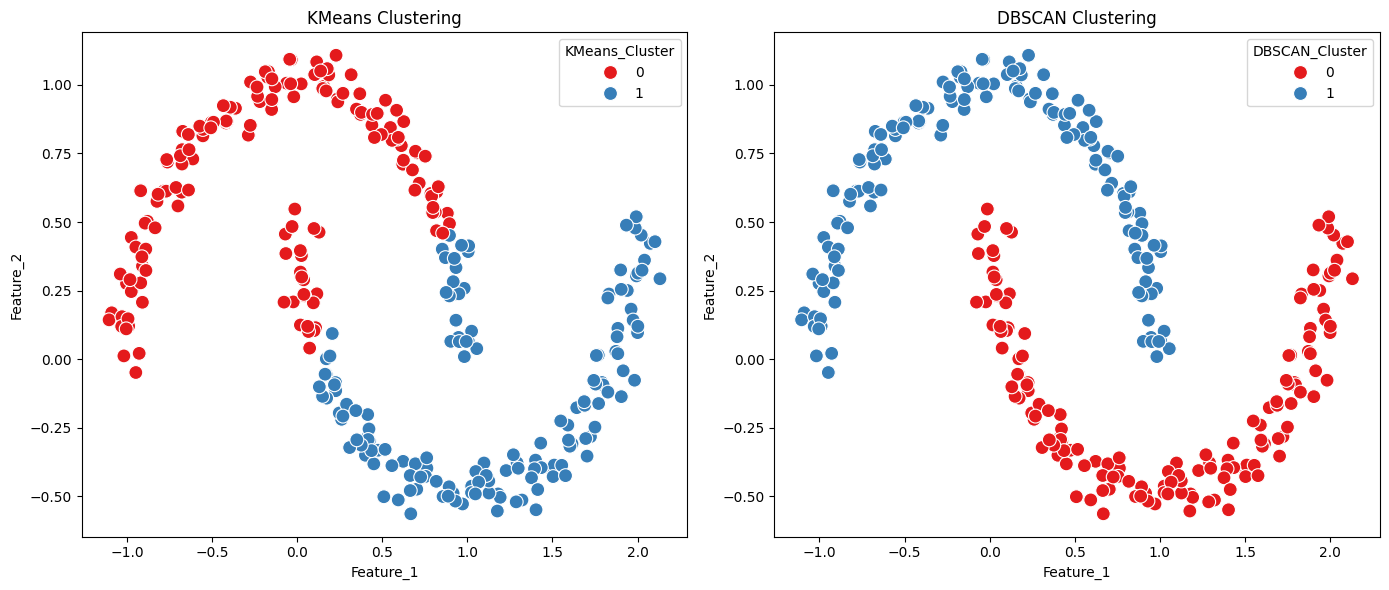

In [27]:
# =========================
# Compare KMeans vs DBSCAN
# =========================

plt.figure(figsize=(14,6))

# KMeans Plot
plt.subplot(1,2,1)

sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['KMeans_Cluster'],
    palette='Set1',
    s=100
)

plt.title("KMeans Clustering")

# DBSCAN Plot
plt.subplot(1,2,2)

sns.scatterplot(
    x=df['Feature_1'],
    y=df['Feature_2'],
    hue=df['DBSCAN_Cluster'],
    palette='Set1',
    s=100
)

plt.title("DBSCAN Clustering")

plt.tight_layout()
plt.show()